# ZORC P11a — SQL Exploration with DuckDB

This notebook uses **DuckDB** to query the ZORC SQLite relational database (`data/zorc_database.db`)
and demonstrates advanced SQL: window functions, CTEs, aggregations.

All queries are taken from `docs/ZORC_P10_P14_architecture.md §P11a`.

| Query | Purpose |
|---|---|
| Q1 | Top 20 P-body candidates by model probability |
| Q2 | Feature distributions by class — window functions |
| Q3 | High N/C flexibility asymmetry AND high m6A density |
| Q4 | Xenium probe panel candidates (prob > 0.85, rrach_count > 15) |
| Q5 | Label noise — ambiguous negatives |
| Q6 | Model performance by BioEmu tier |


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DB = '../data/zorc_database.db'

con = duckdb.connect()
con.execute(f"ATTACH '{DB}' AS zorc (TYPE SQLITE)")
print('DuckDB version:', duckdb.__version__)
print('Connected to:', DB)

DuckDB version: 1.5.2
Connected to: ../data/zorc_database.db


## Database overview

In [2]:
overview = con.execute("""
SELECT
    (SELECT COUNT(*) FROM zorc.genes)       AS n_genes,
    (SELECT COUNT(*) FROM zorc.features)    AS n_features_rows,
    (SELECT COUNT(*) FROM zorc.predictions) AS n_predictions,
    (SELECT SUM(class) FROM zorc.genes)     AS n_positives,
    (SELECT COUNT(*) - SUM(class) FROM zorc.genes) AS n_negatives
""").df()
print(overview.to_string(index=False))

 n_genes  n_features_rows  n_predictions  n_positives  n_negatives
    1501             1501           1501        880.0        621.0


---
## Q1 — Top 20 P-body candidates by model probability

In [3]:
q1 = con.execute("""
SELECT
    g.gene_id,
    g.gene_name,
    p.prob_pos,
    f.rrach_count,
    ROUND(f.idr_percent, 1)            AS idr_pct,
    ROUND(f.utr3_au_content, 3)        AS utr3_au,
    ROUND(f.rmsf_nterm_cterm_ratio, 2) AS rmsf_ratio
FROM zorc.predictions p
JOIN zorc.genes g USING (gene_id)
JOIN zorc.features f USING (gene_id)
WHERE g.class = 1
ORDER BY p.prob_pos DESC
LIMIT 20;
""").df()
q1

,gene_id,gene_name,prob_pos,rrach_count,idr_pct,utr3_au,rmsf_ratio
0,AT3G54230,SUA,0.938071,55.0,79.7,0.698,1.42
1,AT5G64220,AT5G64220,0.937147,49.0,28.4,0.670,1.01
2,AT5G19420,AT5G19420,0.935925,50.0,40.4,0.674,1.09
3,AT4G30100,AT4G30100,0.935577,56.0,42.0,0.603,0.85
4,AT5G08390,AT5G08390,0.935385,36.0,45.9,0.606,0.67
5,AT1G17210,ILP1,0.935150,40.0,66.2,0.682,1.59
6,AT2G36480,AT2G36480,0.934018,44.0,59.8,0.632,1.63
7,AT2G40140,CZF1,0.933432,30.0,47.2,0.686,0.49
8,AT4G14990,AT4G14990,0.932944,39.0,53.4,0.630,2.66
9,AT4G11860,AT4G11860,0.931110,29.0,57.2,0.657,0.69


---
## Q2 — Feature distributions by class using window functions

Quartile assignment for `utr3_au_content` + mean probability per quartile.

In [4]:
q2 = con.execute("""
WITH base AS (
    SELECT
        g.gene_id,
        g.class,
        f.utr3_au_content,
        p.prob_pos,
        NTILE(4) OVER (ORDER BY f.utr3_au_content) AS au_quartile
    FROM zorc.features f
    JOIN zorc.genes g USING (gene_id)
    JOIN zorc.predictions p USING (gene_id)
    WHERE f.utr3_au_content IS NOT NULL
)
SELECT
    au_quartile,
    COUNT(*)                       AS n_genes,
    SUM(class)                     AS n_positives,
    ROUND(AVG(utr3_au_content), 3) AS mean_utr3_au,
    ROUND(AVG(prob_pos), 3)        AS mean_prob_pos
FROM base
GROUP BY au_quartile
ORDER BY au_quartile;
""").df()
q2

,au_quartile,n_genes,n_positives,mean_utr3_au,mean_prob_pos
0,1,376,190.0,0.591,0.513
1,2,375,256.0,0.656,0.656
2,3,375,241.0,0.684,0.627
3,4,375,193.0,0.728,0.519


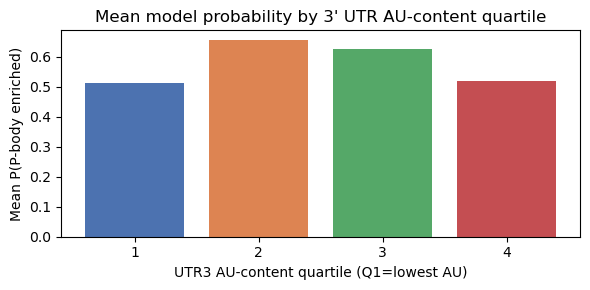

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(q2['au_quartile'], q2['mean_prob_pos'],
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.set_xlabel('UTR3 AU-content quartile (Q1=lowest AU)')
ax.set_ylabel('Mean P(P-body enriched)')
ax.set_title("Mean model probability by 3' UTR AU-content quartile")
ax.set_xticks([1, 2, 3, 4])
plt.tight_layout()
plt.show()

---
## Q3 — High N/C flexibility asymmetry AND high m6A density

Biologically: proteins with exposed N-termini (`rmsf_nterm > 2× rmsf_cterm`) AND
multiple m6A sites (`rrach_per_kb > 15`) — strong P-body signal combination.

Note: explicit `IS NOT NULL` guards are required because DuckDB silently
excludes NULLs in comparisons, and Tier 1 proteins lack BioEmu dynamic features.

In [6]:
q3 = con.execute("""
SELECT
    g.gene_id,
    g.gene_name,
    g.class,
    ROUND(f.rmsf_nterm_cterm_ratio, 2) AS rmsf_ratio,
    ROUND(f.rrach_per_kb, 1)           AS rrach_per_kb,
    ROUND(f.idr_percent, 1)            AS idr_pct,
    ROUND(p.prob_pos, 3)               AS prob_pos
FROM zorc.features f
JOIN zorc.genes g USING (gene_id)
JOIN zorc.predictions p USING (gene_id)
WHERE f.rmsf_nterm_cterm_ratio > 2.0
  AND f.rrach_per_kb > 15.0
  AND f.rmsf_nterm_cterm_ratio IS NOT NULL
  AND f.rrach_per_kb IS NOT NULL
ORDER BY p.prob_pos DESC;
""").df()
print(f'{len(q3)} genes with rmsf_ratio > 2 AND rrach_per_kb > 15')
q3.head(20)

100 genes with rmsf_ratio > 2 AND rrach_per_kb > 15


,gene_id,gene_name,class,rmsf_ratio,rrach_per_kb,idr_pct,prob_pos
0,AT3G14930,HEME1,1,3.05,15.7,1.7,0.925
1,AT5G22510,INV-E,1,2.62,15.9,2.4,0.924
2,AT3G13060,ECT5,1,2.88,16.6,65.0,0.920
3,AT2G19520,FVE,1,5.91,15.6,24.9,0.919
4,AT5G05730,ASA1,1,3.58,15.9,3.2,0.919
5,AT4G33500,AT4G33500,1,2.46,15.0,53.5,0.916
6,AT3G42170,AT3G42170,1,3.46,17.9,14.9,0.915
7,AT4G00570,NAD-ME2,1,3.74,15.4,0.0,0.914
8,AT3G02630,AT3G02630,1,2.44,20.3,1.3,0.909
9,AT4G27070,TSB2,1,2.99,16.5,12.0,0.909


---
## Q4 — Xenium probe panel candidates

Two separate lists for spatial transcriptomics probe design:
- **150 positive probes:** `class=1`, `prob_pos > 0.75`, ordered by `prob_pos DESC` (highest-confidence P-body enriched)
- **150 negative probes:** `class=0`, `prob_pos < 0.25`, ordered by `prob_pos ASC` (lowest-confidence = most convincingly depleted)

Both lists exported together in `results/11a_xenium_probe_candidates.csv` with column `probe_type = 'positive_probe' | 'negative_probe'`.

In [7]:
q4_pos = con.execute("""
SELECT
    g.gene_id,
    g.gene_name,
    g.condition,
    ROUND(p.prob_pos, 4)            AS prob_pos,
    f.rrach_count,
    ROUND(f.utr3_au_content, 4)     AS utr3_au_content,
    ROUND(f.idr_percent, 2)         AS idr_percent,
    'positive_probe'                AS probe_type
FROM zorc.predictions p
JOIN zorc.genes g USING (gene_id)
JOIN zorc.features f USING (gene_id)
WHERE g.class = 1
  AND p.prob_pos > 0.75
ORDER BY p.prob_pos DESC
LIMIT 150;
""").df()

q4_neg = con.execute("""
SELECT
    g.gene_id,
    g.gene_name,
    g.condition,
    ROUND(p.prob_pos, 4)            AS prob_pos,
    f.rrach_count,
    ROUND(f.utr3_au_content, 4)     AS utr3_au_content,
    ROUND(f.idr_percent, 2)         AS idr_percent,
    'negative_probe'                AS probe_type
FROM zorc.predictions p
JOIN zorc.genes g USING (gene_id)
JOIN zorc.features f USING (gene_id)
WHERE g.class = 0
  AND p.prob_pos < 0.25
ORDER BY p.prob_pos ASC
LIMIT 150;
""").df()

q4 = pd.concat([q4_pos, q4_neg], ignore_index=True)

print(f'Positive probes: {len(q4_pos)}  (class=1, prob_pos > 0.75)')
print(f'Negative probes: {len(q4_neg)}  (class=0, prob_pos < 0.25)')
print(f'Total:           {len(q4)}')
print()
print('--- Top 10 positive probes ---')
display(q4_pos.head(10))
print('--- Top 10 negative probes (lowest prob_pos) ---')
display(q4_neg.head(10))

Positive probes: 150  (class=1, prob_pos > 0.75)
Negative probes: 150  (class=0, prob_pos < 0.25)
Total:           300

--- Top 10 positive probes ---


,gene_id,gene_name,condition,prob_pos,rrach_count,utr3_au_content,idr_percent,probe_type
0,AT3G54230,SUA,HS,0.9381,55.0,0.6983,79.66,positive_probe
1,AT5G64220,AT5G64220,HS,0.9371,49.0,0.6697,28.38,positive_probe
2,AT5G19420,AT5G19420,NS,0.9359,50.0,0.6743,40.39,positive_probe
3,AT4G30100,AT4G30100,HS,0.9356,56.0,0.6033,41.95,positive_probe
4,AT5G08390,AT5G08390,HS,0.9354,36.0,0.6061,45.89,positive_probe
5,AT1G17210,ILP1,HS,0.9351,40.0,0.6818,66.18,positive_probe
6,AT2G36480,AT2G36480,HS,0.9340,44.0,0.6316,59.81,positive_probe
7,AT2G40140,CZF1,HS,0.9334,30.0,0.6856,47.24,positive_probe
8,AT4G14990,AT4G14990,HS,0.9329,39.0,0.6295,53.37,positive_probe
9,AT4G11860,AT4G11860,HS,0.9311,29.0,0.6569,57.18,positive_probe


--- Top 10 negative probes (lowest prob_pos) ---


,gene_id,gene_name,condition,prob_pos,rrach_count,utr3_au_content,idr_percent,probe_type
0,AT2G07759,None,depleted,0.0490,0.0,0.58,NaN,negative_probe
1,AT1G28950,None,depleted,0.0490,0.0,0.42,NaN,negative_probe
2,AT5G09585,None,depleted,0.0491,0.0,0.38,NaN,negative_probe
3,AT2G07765,None,depleted,0.0498,1.0,0.58,NaN,negative_probe
4,AT3G52565,None,depleted,0.0498,0.0,0.46,NaN,negative_probe
5,AT2G07792,None,depleted,0.0502,1.0,0.58,NaN,negative_probe
6,AT2G07793,None,depleted,0.0503,1.0,0.50,NaN,negative_probe
7,AT2G07766,None,depleted,0.0503,1.0,0.50,NaN,negative_probe
8,AT4G08345,None,depleted,0.0508,1.0,0.42,NaN,negative_probe
9,AT2G07764,None,depleted,0.0509,0.0,0.48,NaN,negative_probe


In [8]:
q4.to_csv('../results/11a_xenium_probe_candidates.csv', index=False)
print('Saved: results/11a_xenium_probe_candidates.csv')
print(f'  Rows: {len(q4)} ({len(q4_pos)} positive + {len(q4_neg)} negative probes)')
print(f'  Columns: {list(q4.columns)}')

Saved: results/11a_xenium_probe_candidates.csv
  Rows: 300 (150 positive + 150 negative probes)
  Columns: ['gene_id', 'gene_name', 'condition', 'prob_pos', 'rrach_count', 'utr3_au_content', 'idr_percent', 'probe_type']


---
## Q5 — Label noise analysis — ambiguous negatives

Genes labeled `class=0` (depleted) but predicted P-body enriched with
probability 0.35–0.65. These are the most likely label-noise candidates.

In [9]:
q5 = con.execute("""
SELECT
    g.gene_id,
    g.gene_name,
    g.condition,
    ROUND(p.prob_pos, 3)        AS prob_pos,
    ROUND(f.utr3_au_content, 3) AS utr3_au,
    f.rrach_count,
    ROUND(f.idr_percent, 1)     AS idr_pct,
    g.bioemu_tier
FROM zorc.predictions p
JOIN zorc.genes g USING (gene_id)
JOIN zorc.features f USING (gene_id)
WHERE g.class = 0
  AND p.prob_pos BETWEEN 0.35 AND 0.65
ORDER BY p.prob_pos DESC;
""").df()
print(f'{len(q5)} ambiguous negatives (class=0, prob 0.35–0.65)')
print(f'These represent {len(q5)/688*100:.1f}% of all negatives')
q5.head(20)

131 ambiguous negatives (class=0, prob 0.35–0.65)
These represent 19.0% of all negatives


,gene_id,gene_name,condition,prob_pos,utr3_au,rrach_count,idr_pct,bioemu_tier
0,AT1G15880,None,depleted,0.648,0.641,13.0,11.7,2
1,AT5G04950,None,depleted,0.645,0.728,16.0,0.0,1
2,AT4G12440,None,depleted,0.642,0.671,11.0,7.1,1
3,AT4G19230,None,depleted,0.638,0.757,36.0,4.1,1
4,AT2G06530,VPS2,depleted,0.635,0.677,18.0,87.1,3
5,AT3G01470,None,depleted,0.633,0.679,24.0,51.5,3
6,AT1G02130,None,depleted,0.631,0.640,18.0,18.2,2
7,AT2G18890,None,depleted,0.625,0.777,22.0,13.3,2
8,AT2G01530,None,depleted,0.625,0.683,12.0,2.7,1
9,AT5G43350,None,depleted,0.615,0.725,24.0,5.9,1


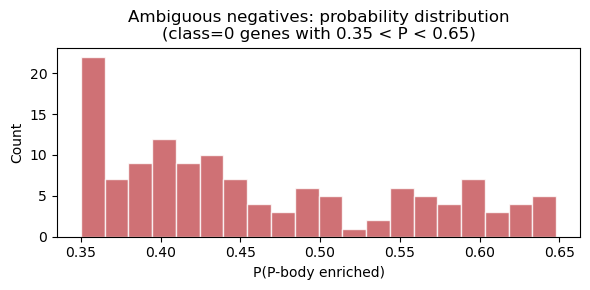

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(q5['prob_pos'], bins=20, color='#C44E52', edgecolor='white', alpha=0.8)
ax.set_xlabel('P(P-body enriched)')
ax.set_ylabel('Count')
ax.set_title('Ambiguous negatives: probability distribution\n'
             '(class=0 genes with 0.35 < P < 0.65)')
plt.tight_layout()
plt.show()

---
## Q6 — Model performance by BioEmu tier

Tests whether dynamic conformational features (Tier 2/3) improve accuracy
over static AF2-only proteins (Tier 1).

In [11]:
q6 = con.execute("""
SELECT
    g.bioemu_tier,
    COUNT(*)                                                         AS n_genes,
    SUM(g.class)                                                     AS n_positives,
    ROUND(AVG(CASE WHEN p.pred = g.class THEN 1.0 ELSE 0.0 END), 3) AS accuracy,
    ROUND(AVG(p.prob_pos), 3)                                        AS mean_prob,
    ROUND(AVG(f.idr_percent), 1)                                     AS mean_idr_pct,
    ROUND(AVG(f.rmsf_mean), 1)                                       AS mean_rmsf
FROM zorc.predictions p
JOIN zorc.genes g USING (gene_id)
JOIN zorc.features f USING (gene_id)
WHERE g.split = 'test'
GROUP BY g.bioemu_tier
ORDER BY g.bioemu_tier;
""").df()
q6

,bioemu_tier,n_genes,n_positives,accuracy,mean_prob,mean_idr_pct,mean_rmsf
0,1,105,63.0,0.705,0.593,2.2,7.8
1,2,56,27.0,0.679,0.589,19.1,12.8
2,3,73,45.0,0.795,0.577,65.8,27.8


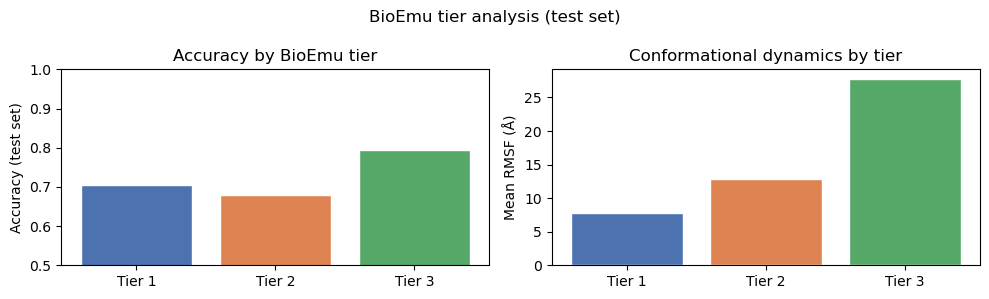

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

labels = [f'Tier {int(t)}' for t in q6['bioemu_tier']]
colors = ['#4C72B0', '#DD8452', '#55A868']

axes[0].bar(labels, q6['accuracy'], color=colors, edgecolor='white')
axes[0].set_ylabel('Accuracy (test set)')
axes[0].set_title('Accuracy by BioEmu tier')
axes[0].set_ylim(0.5, 1.0)

axes[1].bar(labels, q6['mean_rmsf'], color=colors, edgecolor='white')
axes[1].set_ylabel('Mean RMSF (Å)')
axes[1].set_title('Conformational dynamics by tier')

plt.suptitle('BioEmu tier analysis (test set)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Bonus: SHAP coverage check

In [13]:
shap_check = con.execute("""
SELECT
    COUNT(*)                                         AS total_genes,
    COUNT(shap_mrna_length)                          AS with_shap,
    ROUND(COUNT(shap_mrna_length)*100.0/COUNT(*), 1) AS shap_pct,
    ROUND(AVG(CASE WHEN shap_mrna_length IS NOT NULL
                   THEN prob_pos END), 3)            AS mean_prob_with_shap,
    ROUND(AVG(CASE WHEN shap_mrna_length IS NULL
                   THEN prob_pos END), 3)            AS mean_prob_no_shap
FROM zorc.predictions;
""").df()
shap_check

,total_genes,with_shap,shap_pct,mean_prob_with_shap,mean_prob_no_shap
0,1501,496,33.0,0.57,0.583


---
## Bonus: DuckDB querying CSVs directly (no SQLite required)

DuckDB can also query CSVs directly — useful for ad-hoc exploration.

In [14]:
# Bonus: DuckDB can also query CSVs directly without attaching a SQLite file
con_csv = duckdb.connect()
top_shap = con_csv.execute("""
SELECT feature, ROUND(mean_abs_shap, 4) AS mean_abs_shap, rank
FROM read_csv_auto('../results/09f_shap_final.csv')
ORDER BY rank
LIMIT 15
""").df()
con_csv.close()

print('Top 15 features by SHAP importance (P9f final model):')
top_shap

Top 15 features by SHAP importance (P9f final model):


,feature,mean_abs_shap,rank
0,cds_length,0.0209,1
1,mrna_length,0.0197,2
2,rrach_count,0.0194,3
3,di_CG,0.0186,4
4,mfe,0.0164,5
5,di_UA,0.0162,6
6,utr3_au_content,0.0145,7
7,di_UG,0.0140,8
8,n_residues,0.0119,9
9,cds_fraction,0.0103,10


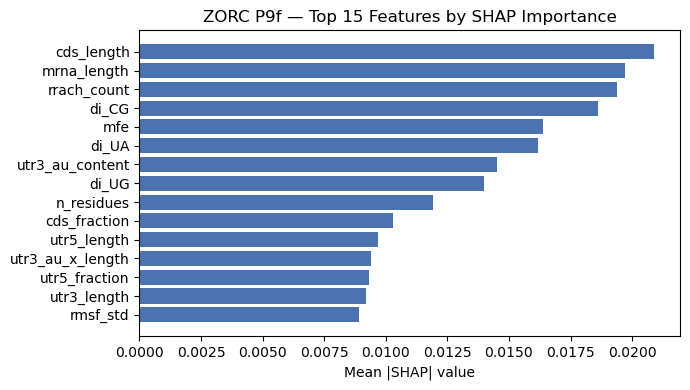

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top_shap['feature'][::-1], top_shap['mean_abs_shap'][::-1], color='#4C72B0')
ax.set_xlabel('Mean |SHAP| value')
ax.set_title('ZORC P9f — Top 15 Features by SHAP Importance')
plt.tight_layout()
plt.show()